### 1. conda 환경 생성 및 활성화
터미널에서 실행:  
conda create -n autogluon_env python=3.10 -y

conda activate autogluon_env

이후 환경 안에서 AutoGluon 설치:

pip install -U pip wheel setuptools

pip install autogluon.tabular -q 


In [1]:
# 파일: autogluon_run.py (예시)

import pandas as pd
from autogluon.tabular import TabularPredictor

# 1) 데이터 로드
train_path = "../data/train.tsv"
test_path = "../data/test.tsv"

# TSV 이므로 sep="\t" 사용
train_df = pd.read_csv(train_path, sep="\t")
test_df = pd.read_csv(test_path, sep="\t")


c:\Users\tj\.conda\envs\autogluon_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

train_df = train_df.drop(columns=['train_id'])
test_df = test_df.drop(columns=['test_id'])


In [3]:

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# 2) 타깃 / ID 컬럼 이름 설정
TARGET_COL = "price"   # 실제 타깃 컬럼명으로 바꿔 주세요
ID_COL = None           # 제출용 ID 컬럼명으로 바꿔 주세요 (없으면 None)


Train shape: (1482535, 7)
Test shape: (693359, 6)


In [ ]:

3) AutoGluon 학습
presets / time_limit 등은 상황에 맞게 조절
predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type=None,          # 회귀/분류 자동 추론, 명시하고 싶으면 "regression"/"multiclass"/"binary"
    path="autogluon_models"     # 모델이 저장될 폴더
).fit(
    train_data=train_df,
    presets="medium_quality_faster_train",  # 빠른 실험용
    time_limit=3600,                        # 최대 1시간 (초 단위), 필요에 따라 조정
)

# 4) 리더보드 확인 (optional)
leaderboard_df = predictor.leaderboard(silent=True)
print(leaderboard_df.head())

# 5) 테스트 데이터 예측
test_preds = predictor.predict(test_df)

# 6) 제출 파일 생성
if ID_COL in test_df.columns:
    submission = pd.DataFrame({
        ID_COL: test_df[ID_COL],
        TARGET_COL: test_preds
    })
else:
    # ID 컬럼이 없다면 단순히 index 기반으로 생성
    submission = pd.DataFrame({
        "id": range(len(test_preds)),
        TARGET_COL: test_preds
    })

submission_path = "submission_autogluon.csv"
submission.to_csv(submission_path, index=False)
print("Saved:", submission_path)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\tj\AppData\Local\Temp\ipykernel_12892\3805669390.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


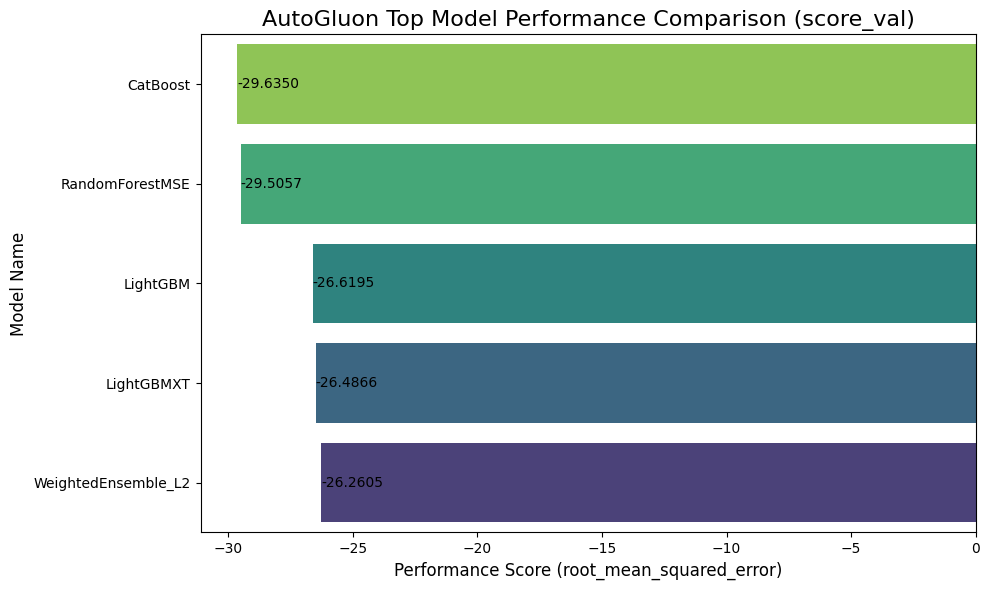

In [9]:
# 1) 가장 중요한 성능 지표 (score_val)를 기준으로 정렬합니다.
# AutoGluon의 리더보드는 이미 점수가 높은 순서(회귀의 경우 -RMSE)로 정렬되어 있습니다.
plot_data = leaderboard_df.copy() # 상위 10개 모델만 시각화 (선택 사항)

# 2) 막대 그래프 생성
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(
    x='score_val', # 성능 지표 (y축 값)
    y='model',     # 모델 이름 (x축 값)
    data=plot_data,
    palette='viridis'
)

# 3) 그래프 제목 및 라벨 설정
plt.title('AutoGluon Top Model Performance Comparison (score_val)', fontsize=16)
plt.xlabel(f'Performance Score ({predictor.eval_metric})', fontsize=12) # 평가 지표 이름을 사용
plt.ylabel('Model Name', fontsize=12)

# 4) 각 막대에 점수 텍스트 추가
for index, row in plot_data.iterrows():
    # 소수점 4자리까지 표시
    bar_plot.text(row['score_val'], index, f'{row["score_val"]:.4f}',
                  color='black', ha="left", va='center')

plt.gca().invert_yaxis() # 성능이 좋은 모델(점수가 높은)이 위에 오도록 y축 순서 뒤집기
plt.tight_layout()
plt.show()

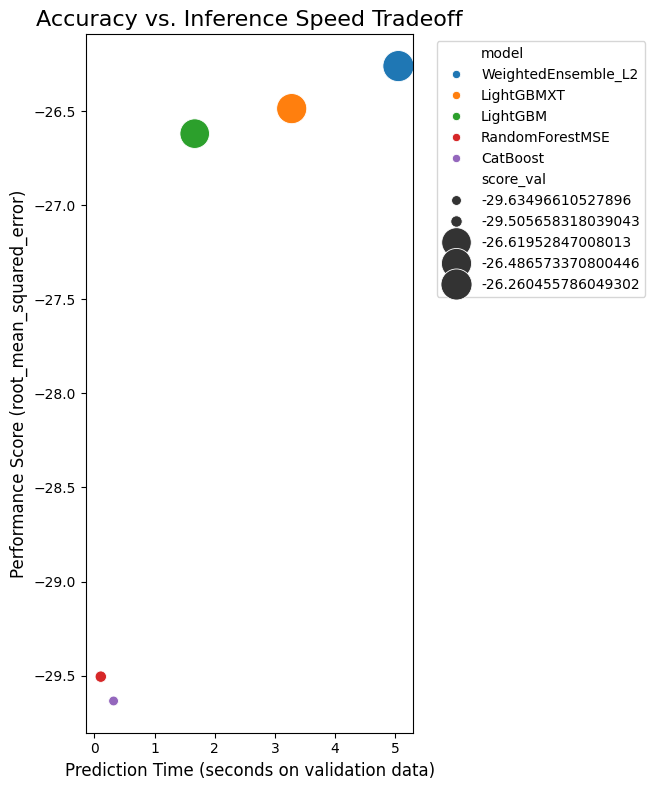

In [10]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x='pred_time_val', # X축: 추론 시간 (낮을수록 좋음)
    y='score_val',     # Y축: 성능 점수 (높을수록 좋음)
    data=leaderboard_df,
    hue='model',       # 모델 종류별로 색상 구분
    size='score_val',  # 성능이 좋을수록 점 크기 키우기
    sizes=(50, 500)
)

plt.title('Accuracy vs. Inference Speed Tradeoff', fontsize=16)
plt.xlabel('Prediction Time (seconds on validation data)', fontsize=12)
plt.ylabel(f'Performance Score ({predictor.eval_metric})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

In [5]:
# 3) AutoGluon 학습
# presets / time_limit 등은 상황에 맞게 조절
predictor_bq = TabularPredictor(
    label=TARGET_COL,
    problem_type=None,          # 회귀/분류 자동 추론, 명시하고 싶으면 "regression"/"multiclass"/"binary"
    path="autogluon_models_bestq"     # 모델이 저장될 폴더
).fit(
    train_data=train_df,
    presets="best_quality",  # 빠른 실험용
    time_limit=600,                        # 최대 1시간 (초 단위), 필요에 따라 조정
)

# 4) 리더보드 확인 (optional)
leaderboard_df = predictor_bq.leaderboard(silent=True)
print(leaderboard_df.head())

# 5) 테스트 데이터 예측
test_preds = predictor_bq.predict(test_df)

# 6) 제출 파일 생성
if ID_COL in test_df.columns:
    submission = pd.DataFrame({
        ID_COL: test_df[ID_COL],
        TARGET_COL: test_preds
    })
else:
    # ID 컬럼이 없다면 단순히 index 기반으로 생성
    submission = pd.DataFrame({
        "id": range(len(test_preds)),
        TARGET_COL: test_preds
    })

submission_path = "submission_autogluon_bestquality.csv"
submission.to_csv(submission_path, index=False)
print("Saved:", submission_path)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          12
Memory Avail:       22.99 GB / 31.91 GB (72.0%)
Disk Space Avail:   341.37 GB / 465.09 GB (73.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is u

AssertionError: Learner is already fit.